<a href="https://colab.research.google.com/github/gurudattamanpreet/Practice/blob/main/pipeline_airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score,mean_absolute_percentage_error
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
# Display Pipeline
from sklearn import set_config
set_config(display='diagram')

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/gurudattamanpreet/datasets/refs/heads/main/Airbnb_Open_Data.csv',low_memory=False)

In [3]:
# pd.set_option('display.max_rows', None)

In [4]:
pd.reset_option('display.max_rows')

In [5]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [6]:
df.shape

(102599, 26)

In [7]:
df.select_dtypes(include=['object']).nunique()

,0
NAME,61281
host_identity_verified,2
host name,13190
neighbourhood group,7
neighbourhood,224
country,1
country code,1
instant_bookable,2
cancellation_policy,3
room type,4


In [8]:
df.drop(['id','host id','license','NAME','host name','country code','country','house_rules','license'],axis=1,inplace=True)

In [9]:
df['last review']=pd.to_datetime(df['last review'])

In [10]:
df['Year']=df['last review'].dt.year

In [11]:
df.dtypes

,0
host_identity_verified,object
neighbourhood group,object
neighbourhood,object
lat,float64
long,float64
instant_bookable,object
cancellation_policy,object
room type,object
Construction year,float64
price,object


In [12]:
df['Year'].value_counts()

,count
Year,
2019.0,42931
2018.0,11455
2022.0,10369
2021.0,6740
2017.0,6601
2016.0,4316
2020.0,2063
2015.0,1874
2014.0,246


In [13]:
df.drop(['last review'],axis=1,inplace=True)

In [14]:
df.duplicated().sum()

np.int64(3636)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.shape

(98963, 18)

In [17]:
df['cancellation_policy'].value_counts()

,count
cancellation_policy,
moderate,33133
flexible,32895
strict,32859


In [18]:
print(df['neighbourhood'].value_counts().to_string())

neighbourhood
Bedford-Stuyvesant            7664
Williamsburg                  7457
Harlem                        5296
Bushwick                      4805
Hell's Kitchen                3853
Upper West Side               3728
Upper East Side               3520
East Village                  3372
Midtown                       3261
Crown Heights                 3154
East Harlem                   2240
Chelsea                       2226
Greenpoint                    2071
Lower East Side               1893
Astoria                       1813
Washington Heights            1721
Financial District            1430
West Village                  1430
Flatbush                      1246
East Flatbush                 1170
Prospect-Lefferts Gardens     1122
Long Island City              1119
Clinton Hill                  1105
Park Slope                     971
Flushing                       949
Murray Hill                    933
Fort Greene                    910
Kips Bay                       895
Ridgew

In [19]:
df.select_dtypes(include=['object']).nunique()

,0
host_identity_verified,2
neighbourhood group,7
neighbourhood,224
instant_bookable,2
cancellation_policy,3
room type,4
price,1151
service fee,231


In [20]:
df['price']=df['price'].str.replace('$','')
df['price']=df['price'].str.replace(',','').astype('float64')
df['service fee']=df['service fee'].str.replace('$','')
df['service fee']=df['service fee'].str.replace(',','').astype('float64')

In [21]:
df.select_dtypes(include=['object']).nunique()

,0
host_identity_verified,2
neighbourhood group,7
neighbourhood,224
instant_bookable,2
cancellation_policy,3
room type,4


In [22]:
df.select_dtypes(include=['object']).columns

Index(['host_identity_verified', 'neighbourhood group', 'neighbourhood',
       'instant_bookable', 'cancellation_policy', 'room type'],
      dtype='object')

In [23]:
r=['host_identity_verified', 'neighbourhood group',
       'instant_bookable', 'cancellation_policy', 'room type']
for i in r:
  print(df[i].value_counts(),'\n')

host_identity_verified
unconfirmed    49400
verified       49274
Name: count, dtype: int64 

neighbourhood group
Manhattan        42292
Brooklyn         40317
Queens           12800
Bronx             2608
Staten Island      915
brookln              1
manhatan             1
Name: count, dtype: int64 

instant_bookable
False    49634
True     49224
Name: count, dtype: int64 

cancellation_policy
moderate    33133
flexible    32895
strict      32859
Name: count, dtype: int64 

room type
Entire home/apt    51908
Private room       44796
Shared room         2144
Hotel room           115
Name: count, dtype: int64 



In [24]:
df['neighbourhood group']=df['neighbourhood group'].replace('manhatan','Manhattan')
df['neighbourhood group']=df['neighbourhood group'].replace('brookln','Brooklyn')

In [25]:
df['neighbourhood group'].value_counts()

,count
neighbourhood group,
Manhattan,42293
Brooklyn,40318
Queens,12800
Bronx,2608
Staten Island,915


In [26]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

,price
price,1.000000
service fee,0.999991
number of reviews,0.004896
reviews per month,0.004164
long,0.002835
Year,0.001224
calculated host listings count,0.000621
availability 365,-0.001918
minimum nights,-0.003093
Construction year,-0.003807


In [27]:
(df['service fee']/df['price']).describe()

,0
count,98477.000000
mean,0.199993
std,0.001151
min,0.192308
25%,0.199609
50%,0.200000
75%,0.200389
max,0.207547


In [28]:
df.drop(['service fee'],axis=1,inplace=True)

In [29]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

,price
price,1.000000
number of reviews,0.004896
reviews per month,0.004164
long,0.002835
Year,0.001224
calculated host listings count,0.000621
availability 365,-0.001918
minimum nights,-0.003093
Construction year,-0.003807
review rate number,-0.004288


<Axes: >

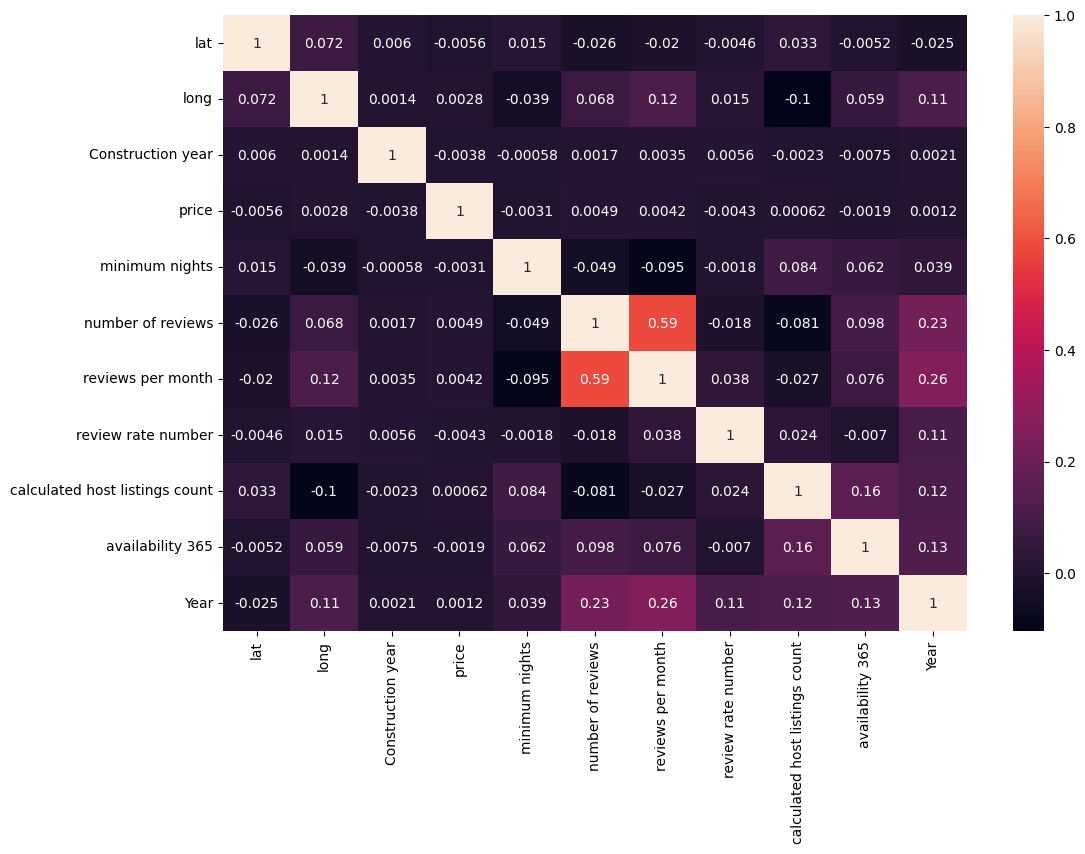

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [31]:
df.select_dtypes(include='number').nunique()

,0
lat,21991
long,17774
Construction year,20
price,1151
minimum nights,153
number of reviews,476
reviews per month,1016
review rate number,5
calculated host listings count,78
availability 365,438


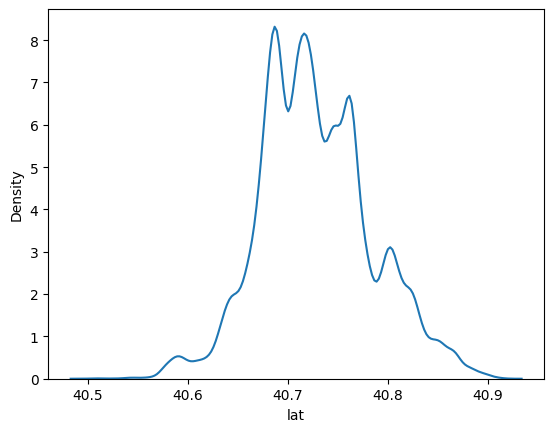

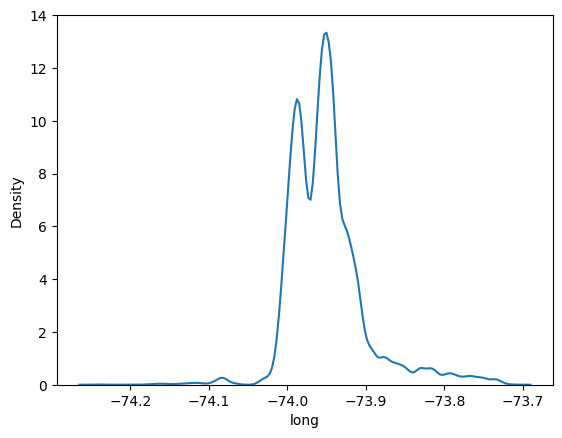

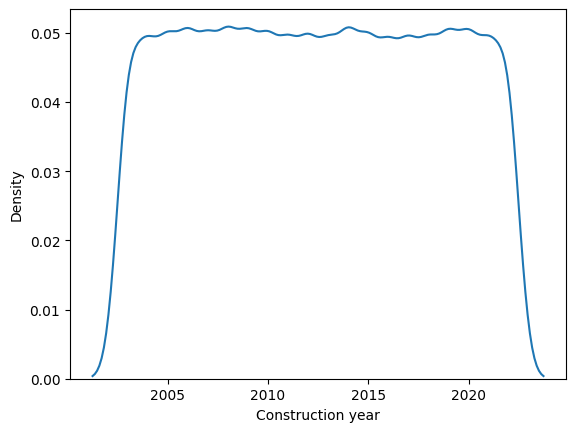

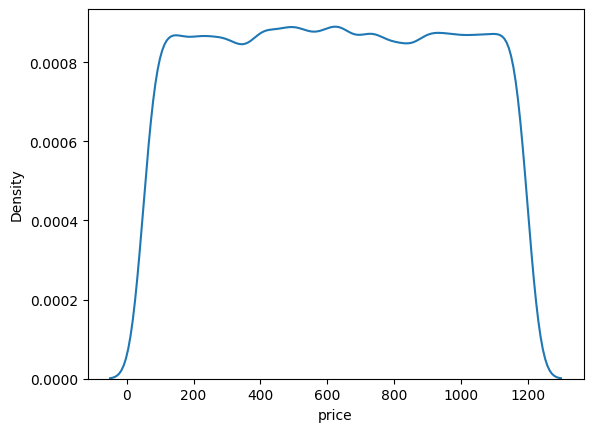

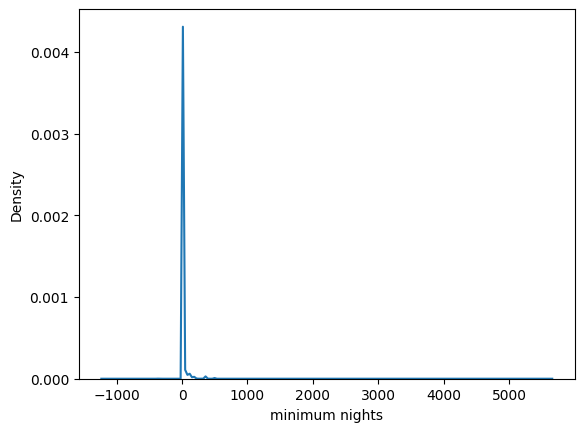

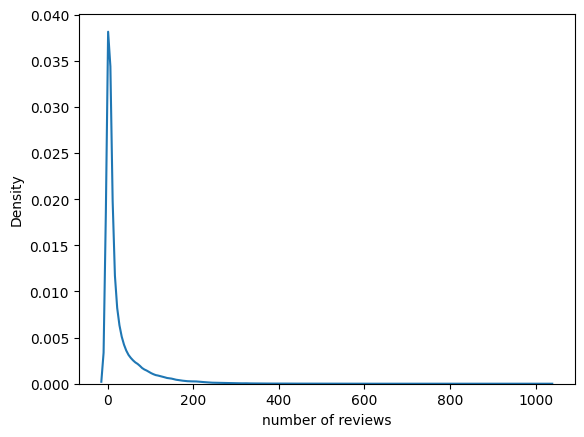

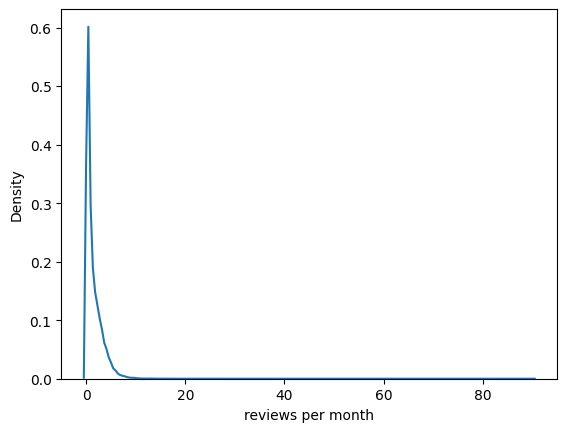

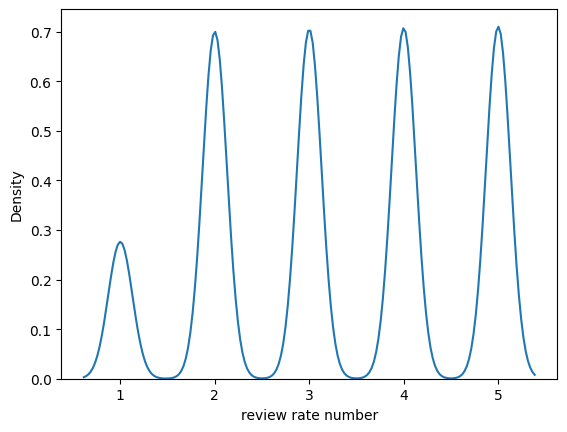

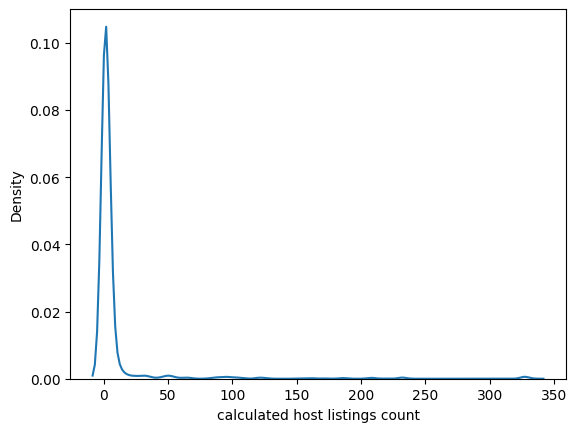

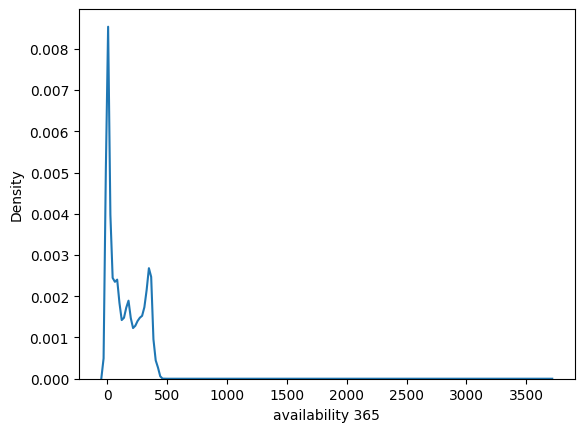

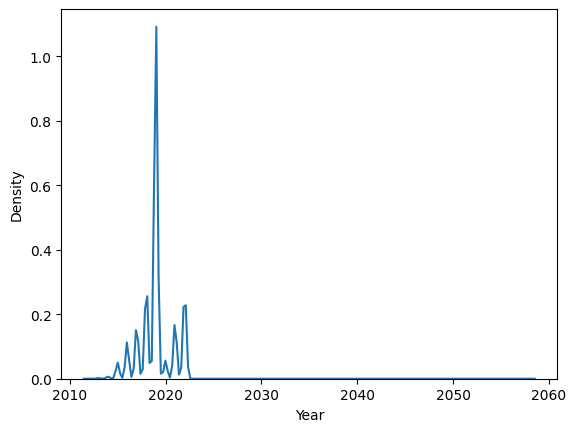

In [32]:
w=df.select_dtypes(include='number').columns

for i in w:
  sns.kdeplot(df[i])
  plt.show()

In [33]:
df=df[df['price'].notna()].copy()

In [34]:
df.shape

(98716, 17)

In [35]:
df['price_log']=np.log1p(df['price'])

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
lat,98708.0,40.728108,0.055852,40.499790,40.688690,40.722325,40.762750,40.91697
long,98708.0,-73.949635,0.049534,-74.249840,-73.982590,-73.954470,-73.932350,-73.70522
Construction year,98506.0,2012.488590,5.766382,2003.000000,2007.000000,2012.000000,2017.000000,2022.00000
price,98716.0,625.260252,331.767279,50.000000,339.000000,625.000000,913.000000,1200.00000
minimum nights,98318.0,8.157377,30.953543,-1223.000000,2.000000,3.000000,5.000000,5645.00000
number of reviews,98536.0,27.593002,49.872494,0.000000,1.000000,7.000000,30.000000,1024.00000
reviews per month,83405.0,1.376725,1.753382,0.010000,0.220000,0.750000,2.000000,90.00000
review rate number,98403.0,3.282573,1.283421,1.000000,2.000000,3.000000,4.000000,5.00000
calculated host listings count,98408.0,7.982481,32.348444,1.000000,1.000000,1.000000,2.000000,332.00000
availability 365,98268.0,142.030437,135.466514,-10.000000,4.000000,99.000000,270.000000,3677.00000


In [37]:
(df['number of reviews']==0).sum()

np.int64(15167)

      here we have 15167 values as zero, hence we need to convert to NaN

In [38]:
df.isna().sum()

,0
host_identity_verified,285
neighbourhood group,28
neighbourhood,15
lat,8
long,8
instant_bookable,100
cancellation_policy,71
room type,0
Construction year,210
price,0


In [39]:
df['number of reviews']=df['number of reviews'].replace(0,np.nan)

In [40]:
df.shape

(98716, 18)

In [41]:
df.isna().sum()

,0
host_identity_verified,285
neighbourhood group,28
neighbourhood,15
lat,8
long,8
instant_bookable,100
cancellation_policy,71
room type,0
Construction year,210
price,0


In [42]:
df.isna().sum()/len(df)*100

,0
host_identity_verified,0.288707
neighbourhood group,0.028364
neighbourhood,0.015195
lat,0.008104
long,0.008104
instant_bookable,0.101301
cancellation_policy,0.071923
room type,0.000000
Construction year,0.212731
price,0.000000


In [43]:
df.dtypes

,0
host_identity_verified,object
neighbourhood group,object
neighbourhood,object
lat,float64
long,float64
instant_bookable,object
cancellation_policy,object
room type,object
Construction year,float64
price,float64


In [44]:
# df['listing age']=df['Year']-df['Construction year']
df['price_per_night'] = df['price'] / df['minimum nights']
df['review_activity'] = df['reviews per month'] * df['number of reviews']
df['booking_intensity'] = df['availability 365'] / df['minimum nights']
df['is_verified_host'] = (df['host_identity_verified'] == 'verified').astype(int)
df['has_review_rate'] = df['review rate number'].notna().astype(int)

In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
lat,98708.0,40.728108,0.055852,40.499790,40.688690,40.722325,40.762750,40.916970
long,98708.0,-73.949635,0.049534,-74.249840,-73.982590,-73.954470,-73.932350,-73.705220
Construction year,98506.0,2012.488590,5.766382,2003.000000,2007.000000,2012.000000,2017.000000,2022.000000
price,98716.0,625.260252,331.767279,50.000000,339.000000,625.000000,913.000000,1200.000000
minimum nights,98318.0,8.157377,30.953543,-1223.000000,2.000000,3.000000,5.000000,5645.000000
number of reviews,83369.0,32.612890,52.688278,1.000000,3.000000,11.000000,39.000000,1024.000000
reviews per month,83405.0,1.376725,1.753382,0.010000,0.220000,0.750000,2.000000,90.000000
review rate number,98403.0,3.282573,1.283421,1.000000,2.000000,3.000000,4.000000,5.000000
calculated host listings count,98408.0,7.982481,32.348444,1.000000,1.000000,1.000000,2.000000,332.000000
availability 365,98268.0,142.030437,135.466514,-10.000000,4.000000,99.000000,270.000000,3677.000000


In [46]:
df['has_review_rate'].isna().sum()

np.int64(0)

In [47]:
df.sort_values(by='availability 365',ascending=False)

,host_identity_verified,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,...,review rate number,calculated host listings count,availability 365,Year,price_log,price_per_night,review_activity,booking_intensity,is_verified_host,has_review_rate
70866,verified,Manhattan,Harlem,40.81623,-73.94907,True,strict,Entire home/apt,2009.0,1186.0,...,5.0,1.0,3677.0,2019.0,7.079184,395.333333,747.04,1225.666667,1,1
8035,verified,Brooklyn,Greenpoint,40.73163,-73.95434,True,moderate,Entire home/apt,2016.0,487.0,...,5.0,1.0,426.0,2015.0,6.190315,162.333333,0.02,142.000000,1,1
15310,verified,Manhattan,Murray Hill,40.75001,-73.97739,False,flexible,Entire home/apt,2003.0,519.0,...,5.0,NaN,426.0,2019.0,6.253829,519.000000,52.20,426.000000,1,1
17057,verified,Manhattan,Lower East Side,40.71429,-73.98755,False,moderate,Private room,2007.0,759.0,...,1.0,1.0,426.0,2017.0,6.633318,379.500000,5.32,213.000000,1,1
156,verified,Manhattan,West Village,40.73226,-74.00401,NaN,NaN,Entire home/apt,2018.0,738.0,...,3.0,1.0,426.0,NaN,6.605298,16.400000,166.16,9.466667,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87071,unconfirmed,Manhattan,Chelsea,40.74179,-73.99855,False,strict,Entire home/apt,2021.0,448.0,...,5.0,1.0,NaN,NaN,6.107023,448.000000,NaN,NaN,0,1
87072,verified,Brooklyn,Boerum Hill,40.68601,-73.98335,True,moderate,Entire home/apt,2016.0,639.0,...,3.0,1.0,NaN,NaN,6.461468,127.800000,NaN,NaN,1,1
87073,unconfirmed,Manhattan,Upper West Side,40.79759,-73.96544,True,moderate,Entire home/apt,2022.0,894.0,...,2.0,1.0,NaN,2016.0,6.796824,894.000000,0.24,NaN,0,1
87099,unconfirmed,Manhattan,Theater District,40.75927,-73.98592,True,flexible,Private room,2008.0,1096.0,...,4.0,1.0,NaN,NaN,7.000334,156.571429,NaN,NaN,0,1


In [48]:
df.drop(index=[70866],inplace=True)

In [49]:
df.dtypes

,0
host_identity_verified,object
neighbourhood group,object
neighbourhood,object
lat,float64
long,float64
instant_bookable,object
cancellation_policy,object
room type,object
Construction year,float64
price,float64


In [50]:
df.drop(['Year'],axis=1,inplace=True)

In [51]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(['price','price_log'],axis=1),df['price_log'],test_size=0.2,random_state=1)

In [52]:
X_train.shape

(78972, 20)

In [53]:
X_test.shape

(19743, 20)

In [54]:
X_train.select_dtypes(include='number').isna().sum()

,0
lat,7
long,7
Construction year,179
minimum nights,313
number of reviews,12322
reviews per month,12292
review rate number,249
calculated host listings count,241
availability 365,372
price_per_night,313


In [55]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
lat,78965.0,40.728122,0.055903,40.50641,40.68868,40.722270,40.76282,40.91697
long,78965.0,-73.949669,0.049410,-74.24442,-73.98262,-73.954490,-73.93245,-73.70522
Construction year,78793.0,2012.485741,5.773395,2003.00000,2007.00000,2012.000000,2018.00000,2022.00000
minimum nights,78659.0,8.099086,29.909399,-1223.00000,2.00000,3.000000,5.00000,5645.00000
number of reviews,66650.0,32.660765,52.648317,1.00000,3.00000,11.000000,39.00000,1024.00000
reviews per month,66680.0,1.379086,1.752403,0.01000,0.22000,0.750000,2.00000,84.49000
review rate number,78723.0,3.283780,1.281380,1.00000,2.00000,3.000000,4.00000,5.00000
calculated host listings count,78731.0,8.017198,32.489411,1.00000,1.00000,1.000000,2.00000,332.00000
availability 365,78600.0,141.777812,134.935409,-10.00000,4.00000,98.000000,269.00000,426.00000
price_per_night,78659.0,287.690716,288.293402,-205.00000,62.00000,195.333333,406.00000,1200.00000


In [56]:
# num_cols = X_train.select_dtypes(include='number').columns.tolist()
# cat_cols = X_train.select_dtypes(include='object').columns.tolist()

# num_imputer = SimpleImputer(strategy='median')
# cat_imputer = SimpleImputer(strategy='most_frequent')

# ct = ColumnTransformer([
#     ('num_imputer', num_imputer, num_cols),
#     ('cat_imputer', cat_imputer, cat_cols)
# ])

# X_train_imputed = pd.DataFrame(ct.fit_transform(X_train),
#                             columns=num_cols + cat_cols, index=X_train.index)
# X_test_imputed = pd.DataFrame(ct.transform(X_test),
#                           columns=num_cols + cat_cols, index=X_test.index)

# X_train_imputed[num_cols] = X_train_imputed[num_cols].apply(
#     pd.to_numeric, errors='coerce')
# X_test_imputed[num_cols] = X_test_imputed[num_cols].apply(
#     pd.to_numeric, errors='coerce')

In [57]:
# Numeric
num_cols = X_train.select_dtypes('number').columns
cat_cols = X_train.select_dtypes('object').columns

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

# Impute numeric
X_train_imputed[num_cols] = SimpleImputer(strategy='median').fit_transform(X_train[num_cols])
X_test_imputed[num_cols] = SimpleImputer(strategy='median').fit(X_train[num_cols]).transform(X_test[num_cols])

# Impute categorical
X_train_imputed[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X_train[cat_cols])
X_test_imputed[cat_cols] = SimpleImputer(strategy='most_frequent').fit(X_train[cat_cols]).transform(X_test[cat_cols])

    SimpleImputer kya karega:
      •	Age me NaN hai → median se fill karega
      •	Salary me NaN hai → median se fill karega
      •	Experience me NaN nahi hai → skip karega automatically ✅

In [58]:
# r=X_train_imputed.select_dtypes(include='number').columns.tolist()
# for i in r:
#   sns.boxplot(x=X_train_imputed[i])
#   plt.show()

In [59]:
z=['minimum nights',
 'number of reviews',
 'reviews per month',
 'calculated host listings count',
 'availability 365',
 'price_per_night',
 'review_activity',
 'booking_intensity']

for i in [X_train_imputed, X_test_imputed]:
    for j in z:
        i[j] = i[j].clip(lower=0)
        i[j + '_log'] = np.log1p(i[j])

X_train_imputed.drop(columns=z, inplace=True)
X_test_imputed.drop(columns=z, inplace=True)

In [60]:
X_train_imputed.shape

(78972, 20)

In [61]:
y_train.shape

(78972,)

In [62]:
X_test_imputed.shape

(19743, 20)

In [63]:
y_test.shape

(19743,)

In [64]:
cat_cols = X_train_imputed.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train_imputed.select_dtypes(exclude=['object']).columns.tolist()

cat_pipeline = Pipeline([('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))])

num_pipeline = Pipeline([('scaler', StandardScaler())])

preprocessor = ColumnTransformer([('num', num_pipeline, num_cols),('cat', cat_pipeline, cat_cols)], remainder='passthrough')

In [65]:
pipe = make_pipeline(preprocessor,LinearRegression())

In [66]:
pipe.fit(X_train_imputed, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['lat', 'long',
                                                   'Construction year',
                                                   'review rate number',
                                                   'is_verified_host',
                                                   'has_review_rate',
                                                   'minimum nights_log',
                                                   'number of reviews_log',
                                                   'reviews per month_log',
                                                   'calculated host listings '
                                                   'count_log',
                                                   'availability 365_log',
                                                   'price_per_night_log',
                                                   'review_activity_log',
                                                   'booking_intensity_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['host_identity_verified',
                                                   'neighbourhood group',
                                                   'neighbourhood',
                                                   'instant_bookable',
                                                   'cancellation_policy',
                                                   'room type'])])),
                ('linearregression', LinearRegression())])

In [67]:
y_train_pred = pipe.predict(X_train_imputed)
y_test_pred = pipe.predict(X_test_imputed)

In [68]:
r2_score(y_test,y_test_pred)

0.954291335502271

In [69]:
r2 = r2_score(y_train, y_train_pred)
r2

0.955532653496016